<a href="https://colab.research.google.com/github/namithashaji/HDFS-Log-Analytics-and-Anomaly-Detection/blob/main/notebooks/model_training_and_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HDFS Log Anomaly Detection — Model Training and Evaluation


# Import Libraries

In [1]:
import ast
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Load Processed Dataset

In [2]:
drive.mount("/content/drive")
DATA_PATH = "/content/drive/MyDrive/HDFS-Log-Analytics/data/processed/processed_hdfs_dataset.csv"
processed_df = pd.read_csv(DATA_PATH)

print("Dataset shape:", processed_df.shape)
processed_df.head()

Mounted at /content/drive
Dataset shape: (575061, 4)


,BlockId,EventSequence,SequenceLength,Label
0,blk_-1000002529962039464,"['E38', 'E38', 'E38', 'E12', 'E34', 'E36', 'E3...",13,0
1,blk_-100000266894974466,"['E12', 'E38', 'E38', 'E38', 'E11', 'E11', 'E1...",28,0
2,blk_-1000007292892887521,"['E38', 'E38', 'E12', 'E38', 'E34', 'E36', 'E3...",13,0
3,blk_-1000014584150379967,"['E38', 'E12', 'E38', 'E38', 'E11', 'E11', 'E1...",29,0
4,blk_-1000028658773048709,"['E38', 'E38', 'E38', 'E12', 'E34', 'E36', 'E3...",19,0


# Convert Event Sequences to Integer IDs

In [3]:
type(processed_df["EventSequence"].iloc[0])

str

In [4]:
processed_df["EventSequence"] = processed_df["EventSequence"].apply(ast.literal_eval)

processed_df["EventSequence"] = processed_df["EventSequence"].apply(
    lambda seq: [int(event.replace("E", "")) for event in seq]
)

print("Example sequence:", processed_df["EventSequence"].iloc[0][:10])

Example sequence: [38, 38, 38, 12, 34, 36, 34, 36, 11, 11]


# Prepare Padded Sequences

In [5]:
max_sequence_length = int(processed_df["SequenceLength"].max())

X = pad_sequences(
    processed_df["EventSequence"],
    maxlen=max_sequence_length,
    padding="post",
    truncating="post"
)

y = processed_df["Label"].values

print("Maximum sequence length:", max_sequence_length)
print("X shape:", X.shape)
print("y shape:", y.shape)

Maximum sequence length: 298
X shape: (575061, 298)
y shape: (575061,)


# Determine Vocabulary Size

In [6]:
max_event_id = max(
    max(sequence)
    for sequence in processed_df["EventSequence"]
)
vocab_size = max_event_id + 1

print("Maximum Event ID:", max_event_id)
print("Vocabulary Size:", vocab_size)

Maximum Event ID: 54
Vocabulary Size: 55


# Sequence-Grouped Train/Test Split


In [7]:
groups = processed_df["EventSequence"].apply(str)

sgkf = StratifiedGroupKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

folds = list(
    sgkf.split(
        processed_df,
        processed_df["Label"],
        groups=groups
    )
)

# Reproduce the selected fold from the detailed experiment
train_idx, test_idx = folds[5]

X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

train_sequences = set(groups.iloc[train_idx])
test_sequences = set(groups.iloc[test_idx])

print("Training samples:", len(train_idx))
print("Testing samples :", len(test_idx))
print("Overlapping sequences:", len(train_sequences.intersection(test_sequences)))

print("\nTraining distribution:")
print(processed_df.iloc[train_idx]["Label"].value_counts())

print("\nTesting distribution:")
print(processed_df.iloc[test_idx]["Label"].value_counts())

Training samples: 527177
Testing samples : 47884
Overlapping sequences: 0

Training distribution:
Label
0    511813
1     15364
Name: count, dtype: int64

Testing distribution:
Label
0    46410
1     1474
Name: count, dtype: int64


# Compute Balanced Class Weights

In [8]:
classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, class_weights_array))

print("Class Weights:")
print(class_weights)

Class Weights:
{np.int64(0): np.float64(0.5150093881945164), np.int64(1): np.float64(17.15624186409789)}


# Build the Class-Weighted Masked LSTM


In [9]:
max_len = max_sequence_length

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(max_len,), dtype=tf.int32),

    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=128,
        mask_zero=True
    ),
    tf.keras.layers.LSTM(128),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 298, 128)       │         7,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 146,945 (574.00 KB)

 Trainable params: 146,945 (574.00 KB)

 Non-trainable params: 0 (0.00 B)

# Train the Model

In [10]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=512,
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.9942 - loss: 0.0502 - val_accuracy: 0.9972 - val_loss: 0.0176
Epoch 2/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9988 - loss: 0.0047 - val_accuracy: 0.9975 - val_loss: 0.0188
Epoch 3/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9991 - loss: 0.0029 - val_accuracy: 0.9975 - val_loss: 0.0243
Epoch 4/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9995 - loss: 0.0024 - val_accuracy: 0.9980 - val_loss: 0.0284


# Training Curves

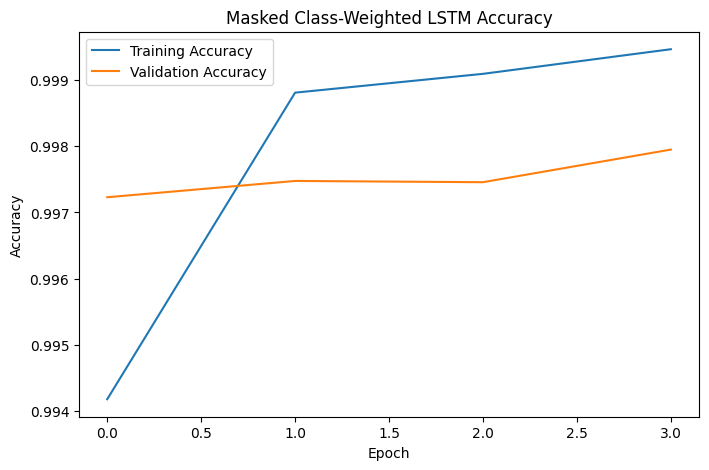

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Masked Class-Weighted LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

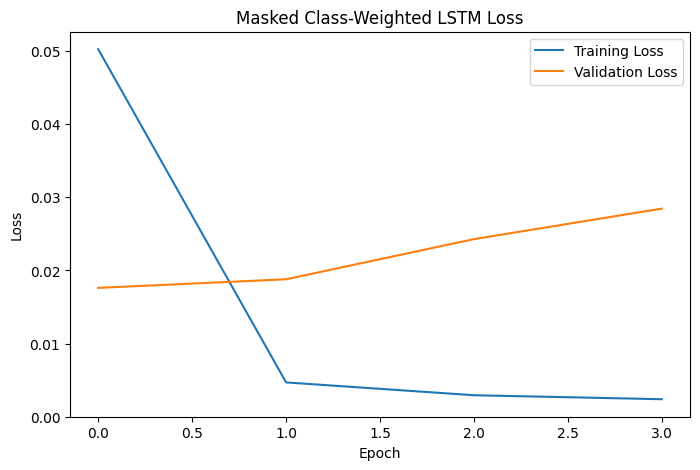

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Masked Class-Weighted LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Test Evaluation

In [13]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

1497/1497 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9979 - loss: 0.0108
Test Loss: 0.0108
Test Accuracy: 0.9979


In [14]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

1497/1497 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


# Classification Report

In [15]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Anomaly"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     46410
     Anomaly       0.94      1.00      0.97      1474

    accuracy                           1.00     47884
   macro avg       0.97      1.00      0.98     47884
weighted avg       1.00      1.00      1.00     47884



# Confusion Matrix

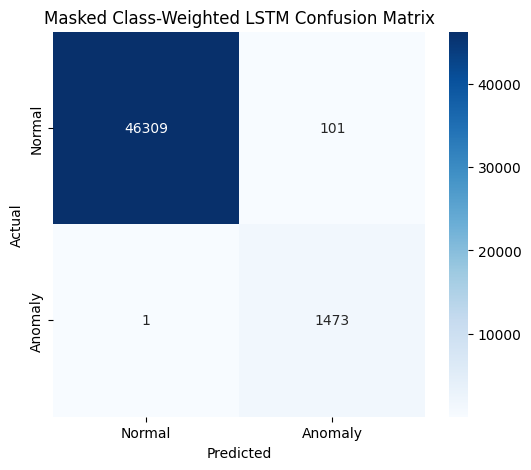

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Anomaly"],
    yticklabels=["Normal", "Anomaly"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Masked Class-Weighted LSTM Confusion Matrix")
plt.show()

# ROC-AUC and PR-AUC

In [17]:
roc_auc = roc_auc_score(y_test, y_pred_prob)
pr_auc = average_precision_score(y_test, y_pred_prob)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

ROC-AUC: 0.9996
PR-AUC: 0.9890


In [18]:
final_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Anomaly Precision": precision_score(y_test, y_pred, zero_division=0),
    "Anomaly Recall": recall_score(y_test, y_pred, zero_division=0),
    "Anomaly F1": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc
}

for metric, value in final_results.items():
    print(f"{metric}: {value:.4f}")

Accuracy: 0.9979
Anomaly Precision: 0.9358
Anomaly Recall: 0.9993
Anomaly F1: 0.9665
ROC-AUC: 0.9996
PR-AUC: 0.9890


# Save Model and Preprocessing Artifacts

In [19]:
model.save("HDFS_Masked_ClassWeighted_LSTM.keras")

with open("class_weights.pkl", "wb") as f:
    pickle.dump(class_weights, f)

preprocessing_config = {
    "max_sequence_length": int(max_sequence_length),
    "vocab_size": int(vocab_size)
}

with open("preprocessing_config.pkl", "wb") as f:
    pickle.dump(preprocessing_config, f)

print("Model and preprocessing artifacts saved successfully.")

Model and preprocessing artifacts saved successfully.
